### Climate Change Trend Analysis and Forecasting

# Table of Contents:

1. [Week 1: Data Acquisition and EDA](#week-1-data-acquisition-and-eda)
2. [Week 2: Feature Engineering](#week-2-feature-engineering)
   - Naive Baseline Model
   - Linear Regression
   - Random Forest Regressor
   - Model Comparison
3. [Week 3: Baseline ML Regression Models](#week-3-baseline-ml-regression-models)
4. [Week 4: ETS Time Series Forecasting](#week-4-ets-time-series-forecasting)
   - ETS Model Introduction
   - Model Fitting
   - Long-Term Forecasting (2024–2043)
   - Forecast Validation
6. [Final Conclusions](#final-conclusions)

## Week 1: Data Acquisition and EDA

This section focuses on collecting and understanding the OWID CO₂ emissions dataset. The dataset structure, important variables, missing values, and basic statistics to understand the characteristics of global emissions data.

In [2]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

urllib.request.urlretrieve(
    url,
    "owid-co2-data.csv"
)

('owid-co2-data.csv', <http.client.HTTPMessage at 0x19a396bc550>)

In [4]:
import os

print(os.getcwd())

c:\cvx\project-ISI_climatechangetrend\notebook


In [5]:
os.listdir()

['ghg_analysis.ipynb', 'owid-co2-data.csv']

In [6]:
import pandas as pd
df = pd.read_csv("owid-co2-data.csv")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#column names
df.columns.tolist()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'cement_co2',
 'cement_co2_per_capita',
 'co2',
 'co2_growth_abs',
 'co2_growth_prct',
 'co2_including_luc',
 'co2_including_luc_growth_abs',
 'co2_including_luc_growth_prct',
 'co2_including_luc_per_capita',
 'co2_including_luc_per_gdp',
 'co2_including_luc_per_unit_energy',
 'co2_per_capita',
 'co2_per_gdp',
 'co2_per_unit_energy',
 'coal_co2',
 'coal_co2_per_capita',
 'consumption_co2',
 'consumption_co2_per_capita',
 'consumption_co2_per_gdp',
 'cumulative_cement_co2',
 'cumulative_co2',
 'cumulative_co2_including_luc',
 'cumulative_coal_co2',
 'cumulative_flaring_co2',
 'cumulative_gas_co2',
 'cumulative_luc_co2',
 'cumulative_oil_co2',
 'cumulative_other_co2',
 'energy_per_capita',
 'energy_per_gdp',
 'flaring_co2',
 'flaring_co2_per_capita',
 'gas_co2',
 'gas_co2_per_capita',
 'ghg_excluding_lucf_per_capita',
 'ghg_per_capita',
 'land_use_change_co2',
 'land_use_change_co2_per_capita',
 'methane',
 'methane_per_capita',
 

In [9]:
df.dtypes

country                            str
year                             int64
iso_code                           str
population                     float64
gdp                            float64
                                ...   
temperature_change_from_n2o    float64
total_ghg                      float64
total_ghg_excluding_lucf       float64
trade_co2                      float64
trade_co2_share                float64
Length: 79, dtype: object

In [10]:
df.shape

(50411, 79)

In [11]:
df['country'].nunique()

254

The OWID CO₂ Emissions Dataset contains information on greenhouse gas emissions and related environmental indicators for countries across multiple years. 

### Key Terms:
1. co2 -  Total carbon dioxide (CO₂) emissions produced by the country during the year. CO2 is emitted in larger quantities, so it is a main cause of total warming.
2. co2_per_capita - Carbon dioxide (CO₂) emissions per person. It is calculated by dividing total CO₂ emissions by the country's population.
3. methane - Total methane (CH₄) emissions released during the year. Methane is a potent greenhouse gas with a much higher warming potential than carbon dioxide over the short term.
4. nitrous_oxide - Total nitrous oxide (N₂O) emissions. Nitrous oxide is primarily emitted through agricultural activities, industrial processes, and the use of fertilizers. It is also the largest remaining contributor to ozone layer depletion.
5. total_ghg - Total greenhouse gas (GHG) emissions from all major greenhouse gases combined. This provides an overall measure of a country's greenhouse gas emissions.
6. year - The year in which the greenhouse gas emissions were recorded.
7. country - The name of the country where the greenhouse gas emissions were recorded.

In [12]:
missing_values=pd.DataFrame({'Missing values':df.isnull().sum(),'Percentage %':(df.isnull().sum()/len(df))*100})
missing_values=missing_values.sort_values(by='Percentage %', ascending=False)
missing_values

,Missing values,Percentage %
share_global_cumulative_other_co2,48241,95.695384
share_global_other_co2,48241,95.695384
other_co2_per_capita,47752,94.725358
cumulative_other_co2,47157,93.545060
other_industry_co2,47157,93.545060
...,...,...
share_of_temperature_change_from_ghg,9173,18.196425
temperature_change_from_co2,9173,18.196425
iso_code,7931,15.732677
year,0,0.000000


The number of null values per column as a percentage of total rows

In [13]:
country_coverage=df.groupby('country').count().sum(axis=1)
country_coverage=country_coverage.sort_values(ascending=False)
country_coverage.head(10)

country
High-income countries    13485
Europe                   13227
United Kingdom           12613
Oceania                  12577
United States            12536
North America            12496
Australia                12403
European Union (27)      12358
Norway                   12241
Europe (excl. EU-27)     12177
dtype: int64

countries that have most complete data coverage

In [14]:
year_coverage=df.groupby('year').count().sum(axis=1)
year_coverage=year_coverage.sort_values(ascending=False)
year_coverage.head(10)

year
2011    15358
2010    15348
2019    15339
2018    15334
2015    15334
2021    15329
2022    15329
2017    15329
2020    15329
2016    15324
dtype: int64

years that have most complete data coverage

In [15]:
# years >= 1990 and sovereign countries
filter_df=df[(df['year'] >= 1990)&(~df['iso_code'].str.startswith('OWID_',na=False))]
filter_df.shape

(8883, 79)

### Data Filtering:

- Records before 1990 were excluded to focus on recent greenhouse gas emission trends. Because of this it provides a relavent time period for better forecasting results.

- regions such as World, Asia, Europe, and similar entries were excluded.  The filtering was performed using the `iso_code` column by removing entries whose ISO codes begin with `OWID_`, leaving only sovereign nations with standard three-letter ISO country codes.

Therefore, the dataset contains annual greenhouse gas emission data for sovereign countries from 1990 onwards and is used for all subsequent EDA and forecasting.


### Exploratory Data Analysis (EDA)

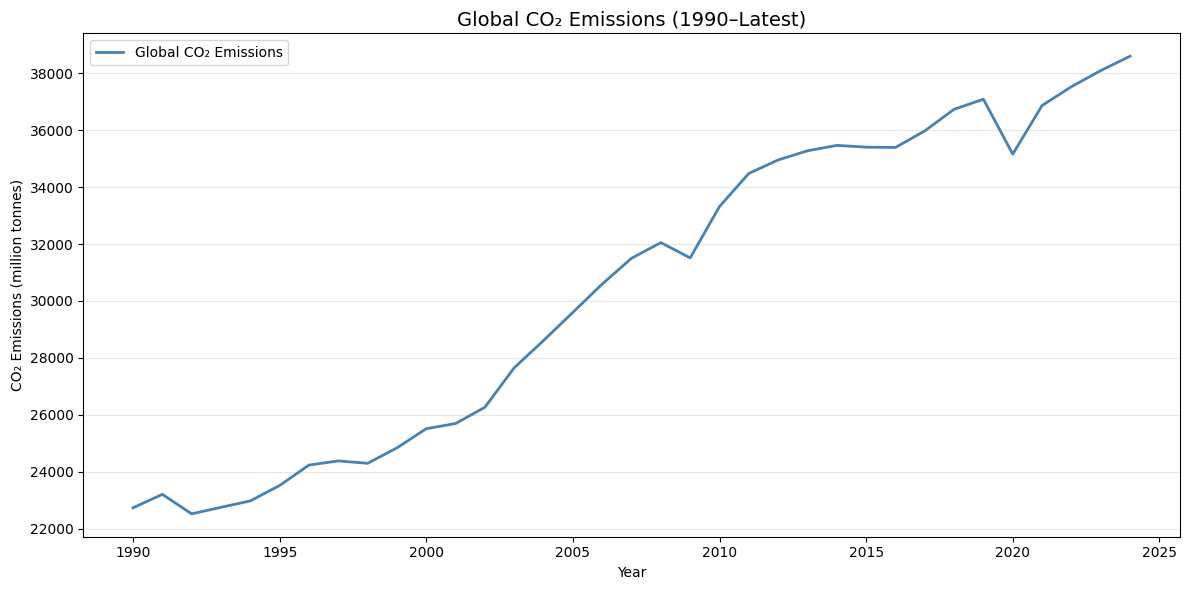

In [16]:
import matplotlib.pyplot as plt
global_co2=df[(df['country'] == 'World')&(df['year'] >= 1990)
]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    global_co2['year'],
    global_co2['co2'],
    linewidth=2,
    color='steelblue',
    label='Global CO₂ Emissions'
)
ax.set_title('Global CO₂ Emissions (1990–Latest)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (million tonnes)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation:

The line chart shows the trend of global CO₂ emissions from 1990 to the latest year available in the dataset. Overall, emissions exhibit an increasing trend over the study period, reflecting continued industrialization, population growth, and energy consumption worldwide. Short-term fluctuations may be observed due to major global events such as economic recessions or the COVID-19 pandemic, but the long-term trend indicates that global CO₂ emissions remain high. 

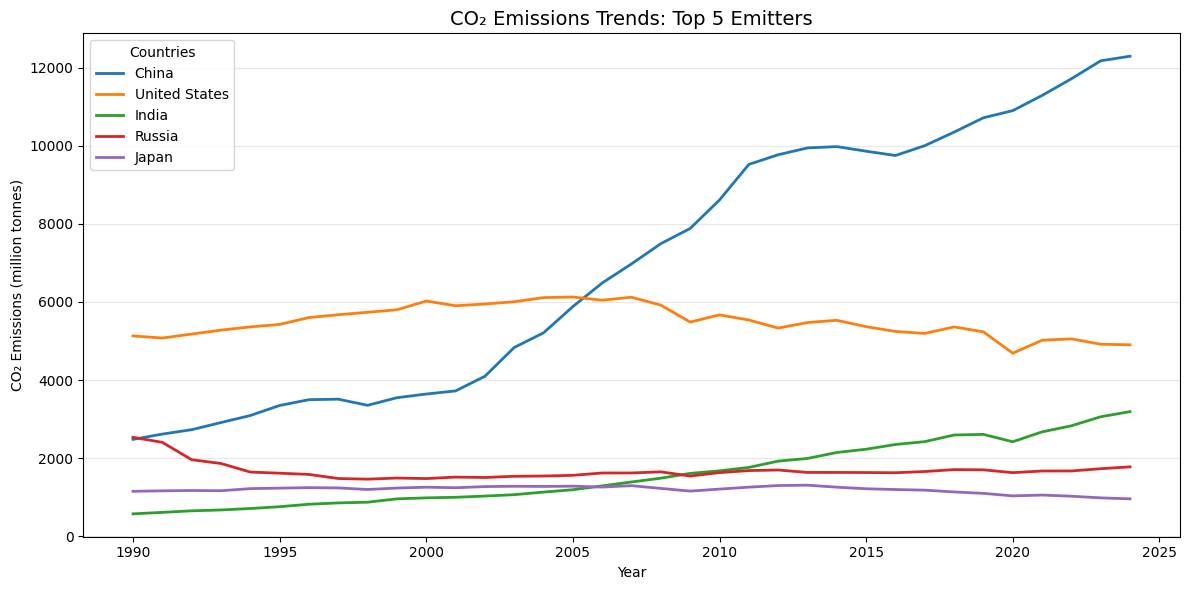

In [17]:
countries=['China','United States','India','Russia','Japan']
top_emission=df[
    (df['country'].isin(countries)) &
    (df['year'] >= 1990)
]
fig, ax = plt.subplots(figsize=(12, 6))
for country in countries:
    data = top_emission[top_emission['country'] == country]
    ax.plot(
        data['year'],
        data['co2'],
        linewidth=2,
        label=country
    )
ax.set_title("CO₂ Emissions Trends: Top 5 Emitters", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ Emissions (million tonnes)")
ax.legend(title="Countries")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### CO₂ Emission Trends Comparison (Top 5 Emitters):

This multi-line chart compares CO₂ emission trends of the five largest emitting countries: China, the United States, India, Russia, and Japan from 1990 to the latest available year.

- China shows a sharp and continuous increase in emissions, especially after the early 2000s.
- The United States shows relatively stable but slightly declining emissions over time. 
- India demonstrates a steady upward trend, though at a lower magnitude compared to China and the US. 
- Russia shows fluctuations with a general decline after the early 1990s.
- Japan remains relatively stable with minor variations.


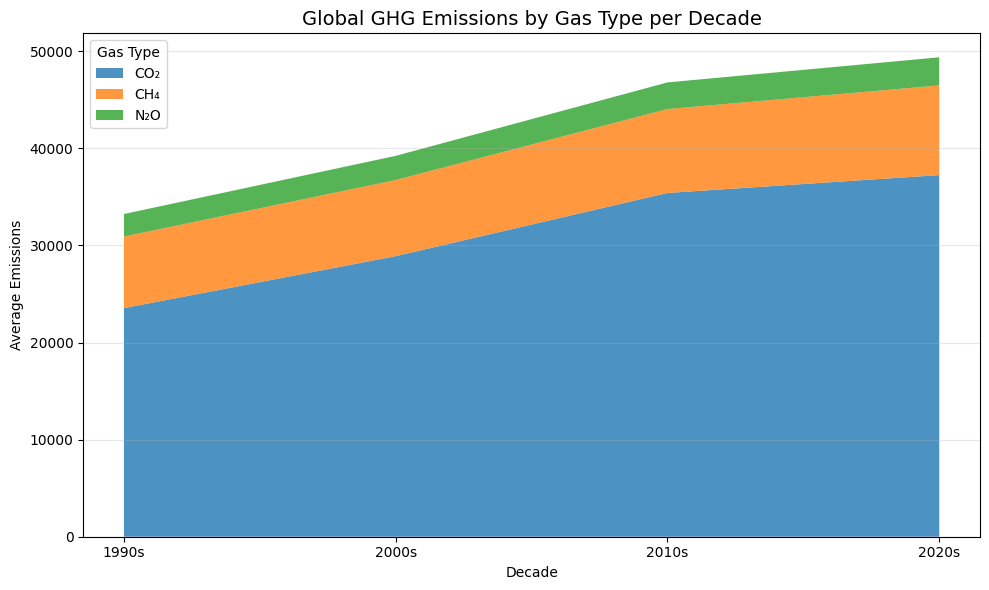

In [18]:
global_co2 = df[
    (df['country'] == 'World')&(df['year'] >= 1990)
].copy()

def get_decade(year):
    if 1990 <= year <= 1999:
        return "1990s"
    elif 2000 <= year <= 2009:
        return "2000s"
    elif 2010 <= year <= 2019:
        return "2010s"
    elif year >= 2020:
        return "2020s"
    
global_co2["decade"] = global_co2["year"].apply(get_decade)

decade_data = global_co2.groupby("decade")[["co2","methane","nitrous_oxide"]].mean()
decade_data = decade_data.reindex(["1990s","2000s","2010s","2020s"])

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    decade_data.index,
    decade_data["co2"],
    decade_data["methane"],
    decade_data["nitrous_oxide"],
    labels=["CO₂", "CH₄", "N₂O"],
    alpha=0.8
)

ax.set_title("Global GHG Emissions by Gas Type per Decade", fontsize=14)
ax.set_xlabel("Decade")
ax.set_ylabel("Average Emissions")
ax.legend(title="Gas Type", loc="upper left")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary of Key patterns observed:
- CO₂ emissions show a steady increasing trend overall and a slight dip around 2020.
- China shows fastest growth, USA stabilizes then slightly declines, India shows steady increase.
- Strong positive relationship between year and emissions

### Summary of week 1:

The dataset was successfully loaded and analysed. Important CO₂-related variables were identified, and initial data quality checks were performed to prepare the dataset for further analysis.

## Week 2: Feature Engineering

This section focuses on transforming the raw CO₂ dataset into a suitable feature dataset for modelling. Additional features such as rolling averages, lag variables, year-on-year changes, and greenhouse gas intensity are created to capture temporal patterns and improve model performance.

In [19]:
filter_df = df[
    (df['year'] >= 1990)&(~df['iso_code'].str.startswith('OWID_', na=False))].copy()
filter_df["decade"]=(filter_df["year"]//10*10).astype(str)+"s"
filter_df[["year","decade"]].head(10)

,year,decade
240,1990,1990s
241,1991,1990s
242,1992,1990s
243,1993,1990s
244,1994,1990s
245,1995,1990s
246,1996,1990s
247,1997,1990s
248,1998,1990s
249,1999,1990s


In [20]:
filter_df=df[
(df['year'] >= 1990) &
(~df['iso_code'].str.startswith('OWID_',na=False))].copy()
# Creation of time index
filter_df['years_since_1990'] = filter_df['year'] - 1990
filter_df[['year', 'years_since_1990']].head(10)

,year,years_since_1990
240,1990,0
241,1991,1
242,1992,2
243,1993,3
244,1994,4
245,1995,5
246,1996,6
247,1997,7
248,1998,8
249,1999,9


### Time Index:

 This converts the calendar year into a continuous numerical variable beginning at 0 for 1990. It is useful for regression and forecasting models because it represents the progression of time in a form that machine learning and statistical algorithms can directly use.

In [21]:
filter_df=filter_df.sort_values(
    ['country','year']).reset_index(drop=True)
filter_df['co2_5yr_rolling_mean']=(filter_df.groupby('country')['co2'].transform(lambda x: x.rolling(window=5).mean()))
filter_df[['country', 'year', 'co2', 'co2_5yr_rolling_mean']].head(10)

,country,year,co2,co2_5yr_rolling_mean
0,Afghanistan,1990,2.024,NaN
1,Afghanistan,1991,1.914,NaN
2,Afghanistan,1992,1.482,NaN
3,Afghanistan,1993,1.487,NaN
4,Afghanistan,1994,1.454,1.6722
5,Afghanistan,1995,1.417,1.5508
6,Afghanistan,1996,1.370,1.4420
7,Afghanistan,1997,1.304,1.4064
8,Afghanistan,1998,1.279,1.3648
9,Afghanistan,1999,1.092,1.2924


### 5-Year Rolling CO₂ Mean:

A 5-year rolling average feature is created to capture smoothed CO₂ emission trends. The rolling window considers five consecutive years of emissions for each country, helping reduce noise and highlight long-term patterns.
The first four years for each country contain NaN values because a 5-year window requires five years of available CO₂ observations. These missing values represent the absence of sufficient historical data to compute the rolling average.

In [22]:
filter_df=filter_df.sort_values(
    ['country', 'year']).reset_index(drop=True)

#Lag features
filter_df['co2_lag1']=(filter_df.groupby('country')['co2'].shift(1))
filter_df['co2_lag2']=(filter_df.groupby('country')['co2'].shift(2))
filter_df['co2_lag3']=(filter_df.groupby('country')['co2'].shift(3))
filter_df[['country', 'year', 'co2', 'co2_lag1', 'co2_lag2', 'co2_lag3']].head(10)

,country,year,co2,co2_lag1,co2_lag2,co2_lag3
0,Afghanistan,1990,2.024,NaN,NaN,NaN
1,Afghanistan,1991,1.914,2.024,NaN,NaN
2,Afghanistan,1992,1.482,1.914,2.024,NaN
3,Afghanistan,1993,1.487,1.482,1.914,2.024
4,Afghanistan,1994,1.454,1.487,1.482,1.914
5,Afghanistan,1995,1.417,1.454,1.487,1.482
6,Afghanistan,1996,1.370,1.417,1.454,1.487
7,Afghanistan,1997,1.304,1.370,1.417,1.454
8,Afghanistan,1998,1.279,1.304,1.370,1.417
9,Afghanistan,1999,1.092,1.279,1.304,1.370


### Lag Features:

Lag features represent previous time-step values of a variable. They provide information that can help models learn patterns and dependencies over time.

For CO₂ emissions data, lag features are created by shifting the annual CO₂ values for each country:
- co2_lag1: CO₂ emissions from the previous year
- co2_lag2: CO₂ emissions from two years before
- co2_lag3: CO₂ emissions from three years before

These features are useful because past emission levels influence future emission trends. Including historical CO₂ values helps forecasting models capture temporal patterns, trends, and changes in emissions over time.


In [23]:
check=filter_df[
    (filter_df['country'].isin(['China', 'India', 'Japan']))&(filter_df['year'].isin([1990, 2000, 2010]))].copy()
check['calculated_co2_per_capita']=(check['co2']*1000000/check['population'])
check[['country','year','co2','population','co2_per_capita','calculated_co2_per_capita']]


,country,year,co2,population,co2_per_capita,calculated_co2_per_capita
1645,China,1990,2483.534,1.153583e+09,2.153,2.152888
1655,China,2000,3643.810,1.269581e+09,2.870,2.870088
1665,China,2010,8610.048,1.351562e+09,6.370,6.370445
3605,India,1990,577.987,8.649722e+08,0.668,0.668215
3615,India,2000,987.065,1.057923e+09,0.933,0.933022
3625,India,2010,1678.530,1.243482e+09,1.350,1.349863
3955,Japan,1990,1154.853,1.233998e+08,9.359,9.358632
3965,Japan,2000,1260.203,1.270278e+08,9.921,9.920687
3975,Japan,2010,1211.090,1.281853e+08,9.448,9.447965


### Verification of CO₂ Per-Capita:

The `co2_per_capita` is verified by calculating CO₂ emissions per person using total CO₂ emissions and population values.

- Three countries (China, India, and Japan) and three different years (1990, 2000, and 2010) are selected for validation.

- Formula: CO₂ per capita= CO₂ emissions / Population

- This confirms that the `co2_per_capita` feature is correctly computed from total CO₂ emissions and population data.



In [24]:
filter_df['ghg_intensity']=(filter_df['total_ghg']/filter_df['gdp']).where(
    (filter_df['total_ghg'].notna())&(filter_df['gdp'].notna())&(filter_df['gdp'] > 0))
filter_df[['country', 'year', 'total_ghg', 'gdp', 'ghg_intensity']].dropna().head(10)

,country,year,total_ghg,gdp,ghg_intensity
0,Afghanistan,1990,13.519,1.306598e+10,1.034671e-09
1,Afghanistan,1991,13.711,1.204736e+10,1.138091e-09
2,Afghanistan,1992,11.543,1.267754e+10,9.105079e-10
3,Afghanistan,1993,10.454,9.834582e+09,1.062984e-09
4,Afghanistan,1994,10.980,7.919856e+09,1.386389e-09
5,Afghanistan,1995,12.110,1.230753e+10,9.839508e-10
6,Afghanistan,1996,14.851,1.207013e+10,1.230393e-09
7,Afghanistan,1997,18.057,1.185075e+10,1.523701e-09
8,Afghanistan,1998,16.691,1.169217e+10,1.427536e-09
9,Afghanistan,1999,18.338,1.151732e+10,1.592211e-09


### Ghg intensity: 

The `ghg_intensity` is calculated as the ratio of total greenhouse gas emissions to GDP.

- Formula= GHG Intensity=Total GHG Emissions / GDP

- The calculation is performed only when both `total_ghg` and `gdp` values are available and GDP is greater than zero. This prevents invalid calculations due to missing values or division by zero.The resulting values are small because total GHG emissions are measured in million tonnes, while GDP is measured in US dollars. 

In [25]:
missing_gdp=filter_df[filter_df['gdp'].isna()]
missing_gdp[['country', 'year', 'total_ghg', 'gdp']]

,country,year,total_ghg,gdp
33,Afghanistan,2023,38.675,NaN
34,Afghanistan,2024,39.886,NaN
35,Africa,1990,2634.715,NaN
36,Africa,1991,2720.797,NaN
37,Africa,1992,2829.095,NaN
...,...,...,...,...
8812,Yemen,2024,26.665,NaN
8846,Zambia,2023,98.810,NaN
8847,Zambia,2024,99.033,NaN
8881,Zimbabwe,2023,31.029,NaN


### Missing GDP data:

- A total of 3462 country-year observations were identified where GDP values are unavailable. As these records cannot produce valid GHG intensity values. Instead of removing these observations, they are kept in the dataset and the corresponding `ghg_intensity` values remain as `NaN`. 

In [26]:
filter_df=filter_df.sort_values(['country', 'year']).reset_index(drop=True)
#Absolute change(Year-on-year)
filter_df['co2_yoy_change']=(filter_df.groupby('country')['co2'].diff())
#Percentage change(Year-on-year) 
filter_df['co2_yoy_pct_change']=(filter_df.groupby('country')['co2'].pct_change()*100)
filter_df[['country', 'year', 'co2', 'co2_yoy_change', 'co2_yoy_pct_change']].head(10)

,country,year,co2,co2_yoy_change,co2_yoy_pct_change
0,Afghanistan,1990,2.024,NaN,NaN
1,Afghanistan,1991,1.914,-0.110,-5.434783
2,Afghanistan,1992,1.482,-0.432,-22.570533
3,Afghanistan,1993,1.487,0.005,0.337382
4,Afghanistan,1994,1.454,-0.033,-2.219233
5,Afghanistan,1995,1.417,-0.037,-2.544704
6,Afghanistan,1996,1.370,-0.047,-3.316867
7,Afghanistan,1997,1.304,-0.066,-4.817518
8,Afghanistan,1998,1.279,-0.025,-1.917178
9,Afghanistan,1999,1.092,-0.187,-14.620797


### Year-on-Year CO₂ Change

`co2_yoy_change` represents the absolute annual change in CO₂ emissions:

- Formula: CO₂ YoY Change=CO₂_t - CO₂_(t-1)

`co2_yoy_pct_change` represents the percentage change compared with the previous year:

- Formula: CO₂ YoY % Change=CO₂_t - CO₂_(t-1)/CO₂_(t-1)*100

The first year for each country contains `NaN` values because there is no previous year available for comparison.

In [27]:
#Top 5 countries with the highest average annual CO2 growth rate since 1990
filter_df['co2_yoy_pct_change']=(filter_df['co2_yoy_pct_change'].replace([float('inf'), -float('inf')], np.nan))
avg_growth=(filter_df.groupby('country')['co2_yoy_pct_change'].mean().sort_values(ascending=False))
top_growth_countries=avg_growth.head(5)
top_growth_countries

country
Equatorial Guinea                  52.686369
Kuwait                             37.859672
Sint Maarten (Dutch part)          22.447669
Bonaire Sint Eustatius and Saba    21.891106
Curacao                            20.185451
Name: co2_yoy_pct_change, dtype: float64

### Top 5 Countries with highest average annual CO₂ growth rate since 1990

- To identify countries with the fastest increase in CO₂ emissions, the average annual year-on-year CO₂ percentage change was calculated for each country.

Note:Very high growth rates may occur for countries with low initial emission levels, where small absolute increases result in large percentage changes.

In [28]:
#Countries with average CO2 emissions above 1 million tonnes
major_emitters=(filter_df.groupby('country')['co2'].mean())
major_emitters=major_emitters[major_emitters>1].index
avg_growth_major=(filter_df[filter_df['country'].isin(major_emitters)].groupby('country')['co2_yoy_pct_change'].mean().sort_values(ascending=False))
avg_growth_major.head(5)

country
Equatorial Guinea    52.686369
Kuwait               37.859672
Curacao              20.185451
Laos                 13.611132
Haiti                12.137515
Name: co2_yoy_pct_change, dtype: float64

### Top CO₂ growth countries among major emitters

- Percentage growth rates can be misleading for countries with very low initial CO₂ emissions, as small absolute increases may result in extremely high percentage changes.
- To reduce this effect, countries with average annual CO₂ emissions greater than 1 million tonnes were selected as major emitters. The average annual CO₂ year-on-year percentage growth rate was then calculated for these countries.

- This analysis identifies countries with relatively higher emission growth rates while considering a minimum emission level.
- The results should be interpreted along with absolute emission values, as a high growth percentage does not always indicate a large contribution to global CO₂ emissions.

In [29]:
#Top 5 countries with largest CO₂ reductions since 1990
country_data = filter_df[filter_df['iso_code'].notna()&(~filter_df['iso_code'].str.startswith('OWID_', na=False))].copy()

co2_start=(country_data[country_data['year']==1990][['country', 'co2']].rename(columns={'co2': 'co2_1990'}))
latest_year=country_data['year'].max()

co2_latest=(country_data[country_data['year']==latest_year][['country', 'co2']].rename(columns={'co2': 'co2_latest'}))
co2_change=co2_start.merge(co2_latest,on='country',how='inner')

co2_change['co2_reduction']=(co2_change['co2_latest'] -co2_change['co2_1990'])
largest_reductions=(co2_change.sort_values('co2_reduction').head(5))
largest_reductions

,country,co2_1990,co2_latest,co2_reduction
160,Russia,2536.284,1780.524,-755.760
204,Ukraine,706.526,142.498,-564.028
76,Germany,1054.796,572.319,-482.477
206,United Kingdom,601.945,312.906,-289.039
207,United States,5131.761,4904.120,-227.641


### Countries with largest CO₂ reductions since 1990

To identify countries with the largest absolute reductions in CO₂ emissions, the change between emissions in 1990 and the latest available year was calculated.

Formula: CO₂ Change=CO₂_latest - CO₂_1990

- Negative values indicate a reduction in emissions, with more negative values representing larger decreases.
- Only individual countries were considered by removing aggregate entities such as regions and economic groups using valid ISO country codes.
- The analysis identifies the countries that experienced the largest absolute declines in annual CO₂ emissions since 1990.

In [30]:
countries = ['China','India','Japan','United States','Russia','Germany','United Kingdom','Brazil','Canada','Australia']
ghg_features = filter_df[filter_df['country'].isin(countries)][
    ['country','year','co2','co2_per_capita','co2_5yr_rolling_mean','co2_lag1','co2_lag2','co2_lag3','co2_yoy_pct_change','years_since_1990']].copy()

ghg_features = (ghg_features.sort_values(['country', 'year']).reset_index(drop=True))
ghg_features.head()


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,years_since_1990
0,Australia,1990,278.061,16.236,NaN,NaN,NaN,NaN,NaN,0
1,Australia,1991,279.437,16.103,NaN,278.061,NaN,NaN,0.494855,1
2,Australia,1992,284.433,16.208,NaN,279.437,278.061,NaN,1.787881,2
3,Australia,1993,288.780,16.294,NaN,284.433,279.437,278.061,1.528304,3
4,Australia,1994,293.613,16.405,284.8648,288.780,284.433,279.437,1.673592,4


In [31]:
print("Shape:", ghg_features.shape)
ghg_features.isna().sum()

Shape: (350, 10)


country                  0
year                     0
co2                      0
co2_per_capita           0
co2_5yr_rolling_mean    40
co2_lag1                10
co2_lag2                20
co2_lag3                30
co2_yoy_pct_change      10
years_since_1990         0
dtype: int64

### Check Missing values:
Missing values are expected in some engineered features:
- `co2_5yr_rolling_mean`: The first four years of each country's data do not have enough previous observations to calculate a 5-year rolling average.
- `co2_lag1`, `co2_lag2`, and `co2_lag3`: The first few years do not have previous years available for lag calculation.
- `co2_yoy_pct_change`: The first year of each country has no previous year for comparison.
- `ghg_intensity`: Missing values occur where GDP data is unavailable.

These missing values are a natural consequence of time-series feature engineering and can be handled during the modelling stage.

In [32]:
ghg_features.to_csv("ghg_features.csv", index=False)

### Summary of week 2:
The feature engineering process successfully converted the raw dataset into a structured modelling dataset. Time-dependent features such as lag values and rolling averages help represent historical emission behaviour, while additional indicators provide useful information for forecasting CO₂ emissions.

## Week 3: Baseline ML Regression Models

### Prediction Task:

The goal of this project is to predict the CO₂ emissions for the next year using previous emission data.

For each country and year, the model uses the features present to predict the CO₂ emissions for the following year.
Input: Features for country C in year Y
Output: CO₂ emissions for country C in year Y + 1

The model uses features such as:
- CO₂ emissions
- CO₂ per capita
- 5-year rolling mean
- Lag features 
- Year-on-year percentage change
- GHG intensity 

### Target Variable and Input Features:

- Target Variable-co2
- Input Features-country, year, co2_per_capita, co2_5yr_rolling_mean, co2_lag1, co2_lag2, co2_lag3, co2_yoy_pct_change, ghg_intensity.


### Choice of Supervised Regression:

- This problem is a supervised regression because the target variable (`co2`) is a continuous numerical value.
- The model is trained using past data where both the input features and the corresponding CO₂ emissions are known. It learns the relationship between these features and CO₂ emissions to predict emissions for the upcoming years.
- Regression algorithms are suitable because the goal is to estimate a numerical value rather than classify data into categories.

### Train-Test Split
Since this project involves time-series forecasting, the data is split based on time.

For each of the 10 selected countries:

- Training period: 1990–2018
- Testing period: 2019–2023 (latest available years)

The test period includes the COVID-19 pandemic period, where global emissions experienced an unusual dip in 2020 followed by subsequent recovery. This provides a realistic evaluation of the model's ability to handle unexpected changes.

### Why temporal splitting is essential?
Random train-test splitting is not suitable for time-series data because it can mix future observations with past observations. This may cause data leakage and give an unrealistic estimate of model performance.

A temporal split ensures that the model is trained only on past data and tested on future unseen data, which matches the real-world forecasting scenario.

In [33]:
train_data=ghg_features[ghg_features['year']<=2018].copy()
test_data=ghg_features[(ghg_features['year']>=2019)&(ghg_features['year']<=2023)].copy()
print("Training samples:", train_data.shape)
print("Testing samples:", test_data.shape)

Training samples: (290, 10)
Testing samples: (50, 10)


In [34]:
#number of training an testing samples per country
train_count=(train_data.groupby('country').size().rename('training_samples'))
test_count=(test_data.groupby('country').size().rename('testing_samples'))
sample=pd.concat([train_count, test_count],axis=1)
sample

,training_samples,testing_samples
country,,
Australia,29,5
Brazil,29,5
Canada,29,5
China,29,5
Germany,29,5
India,29,5
Japan,29,5
Russia,29,5
United Kingdom,29,5


## Naive Baseline Model:

A naive baseline model is implemented as a reference model for comparison with more advanced forecasting models.

The baseline assumes that the CO₂ emissions for the next year will remain unchanged from the current year (no change model).

Prediction rule: Predicted CO₂ (Y+1) = Actual CO₂ (Y) [Predict next year CO2 = current year CO2]

The baseline performance is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

The evaluation is performed separately for each of the 10 selected countries on the test period (2019–2023).

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
baseline_results=[]
for country in countries:
    country_test=test_data[test_data['country']==country].copy()
    country_test['naive_prediction']=(country_test['co2'].shift(1))
    country_test=country_test.dropna(subset=['naive_prediction'])
    mae=np.sqrt(mean_squared_error(country_test['co2'],country_test['naive_prediction']))
    rmse=np.sqrt(mean_squared_error(country_test['co2'],country_test['naive_prediction']))
    baseline_results.append([country,mae,rmse])
baseline_results=pd.DataFrame(baseline_results,columns=['country','MAE','RMSE'])
baseline_results

,country,MAE,RMSE
0,China,380.264314,380.264314
1,India,210.551410,210.551410
2,Japan,42.735691,42.735691
3,United States,326.759549,326.759549
4,Russia,51.010591,51.010591
5,Germany,50.791896,50.791896
6,United Kingdom,26.115424,26.115424
7,Brazil,29.459077,29.459077
8,Canada,28.667970,28.667970
9,Australia,9.862915,9.862915


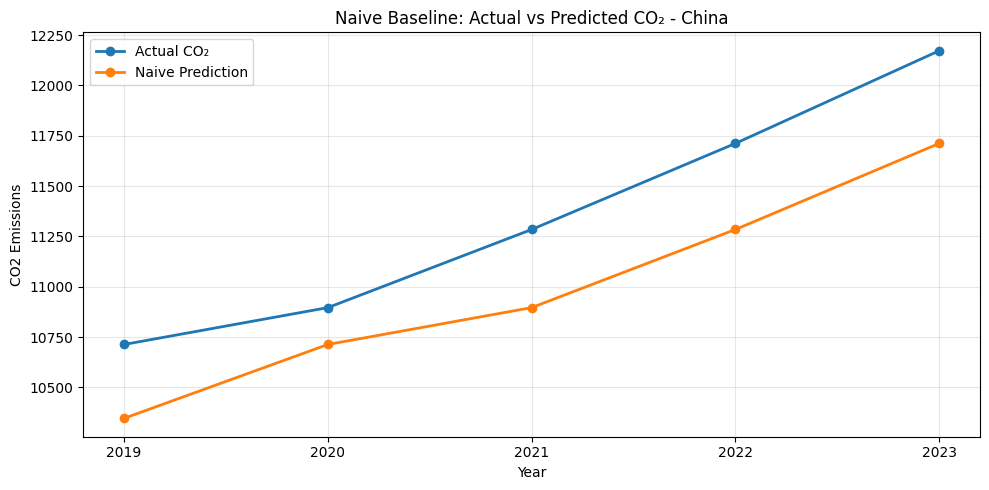

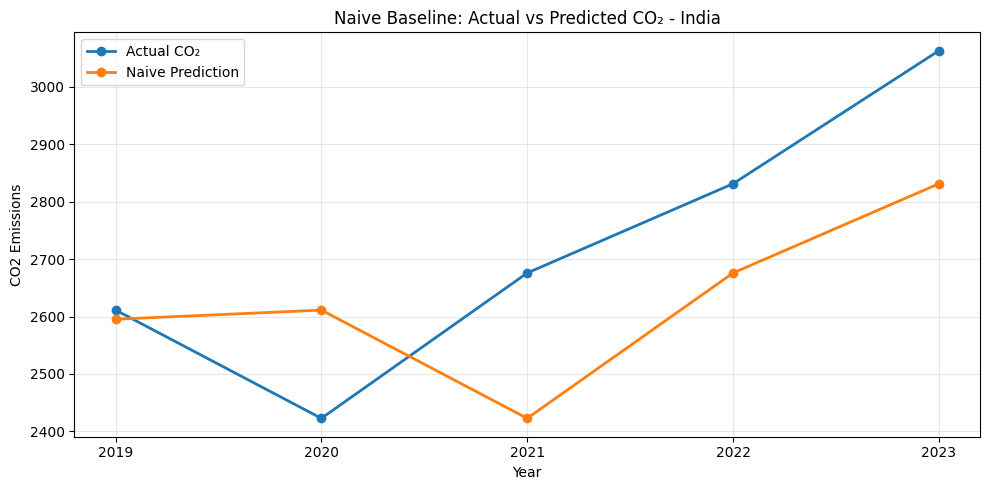

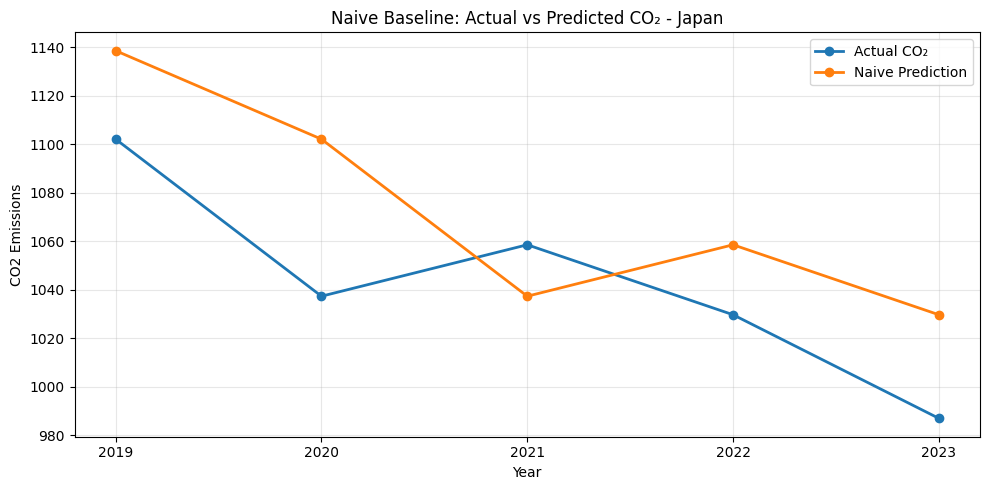

In [36]:
#Plot actual Vs predicted values for 3 countries
plot_countries=['China','India','Japan']
combined_data=pd.concat([train_data, test_data])
combined_data=combined_data.sort_values(['country', 'year'])
combined_data['naive_prediction'] = (combined_data.groupby('country')['co2'].shift(1))
baseline_plot=combined_data[combined_data['year'] >= 2019].copy()
for country in plot_countries:
    data=baseline_plot[baseline_plot['country']==country].copy()
    plt.figure(figsize=(10,5))
    plt.plot(
        data['year'],
        data['co2'],
        marker='o',
        linewidth=2,
        label='Actual CO₂'
    )
    plt.plot(
        data['year'],
        data['naive_prediction'],
        marker='o',
        linewidth=2,
        label='Naive Prediction'
    )
    plt.title(f"Naive Baseline: Actual vs Predicted CO₂ - {country}")
    plt.xlabel("Year")
    plt.ylabel('CO2 Emissions')
    plt.xticks(data['year'])   # fixes .0 and .5 issue
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Observations:
- The naive baseline follows the general emission trend but cannot capture sudden increases or decreases in CO₂ emissions.
- Large differences between actual and predicted values occur during years with significant emission changes, such as the COVID-19 period in 2020. This highlights the limitation of using a simple no-change assumption for forecasting.

## Linear Regression Model:

A Linear Regression model is implemented as a supervised regression approach to predict future CO₂ emissions.The model learns the relationship between the engineered input features and the target variable (`co2`).

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

features=[
    'co2_5yr_rolling_mean',
    'co2_lag1',
    'co2_lag2',
    'co2_lag3',
    'co2_yoy_pct_change',
    'years_since_1990'
]
target='co2'
lr_results=[]
lr_models={}

for country in countries:
    train_country=train_data[train_data['country']==country].copy()
    test_country=test_data[test_data['country']==country].copy()
    
    train_country=train_country.dropna(subset=features+[target])
    test_country=test_country.dropna(subset=features + [target])
    X_train=train_country[features]
    y_train=train_country[target]
    
    X_test=test_country[features]
    y_test=test_country[target]
    
    model=LinearRegression()
    model.fit(X_train, y_train)

    y_pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    
    lr_results.append([country, mae, rmse])
    lr_models[country]=model
    
lr_results=pd.DataFrame(lr_results,columns=['country','MAE','RMSE'])
lr_results


,country,MAE,RMSE
0,China,48.361967,53.991104
1,India,57.651297,80.925158
2,Japan,5.584316,5.899031
3,United States,27.655346,38.543932
4,Russia,1.931693,2.148285
5,Germany,10.916884,12.877190
6,United Kingdom,8.452217,9.918509
7,Brazil,3.482761,4.168151
8,Canada,0.520432,0.637063
9,Australia,0.663314,0.759730


- co2_per_capita is retained only for verification/analysis.
- It is excluded from ML features to avoid target leakage.

In [40]:
len(lr_models)

10

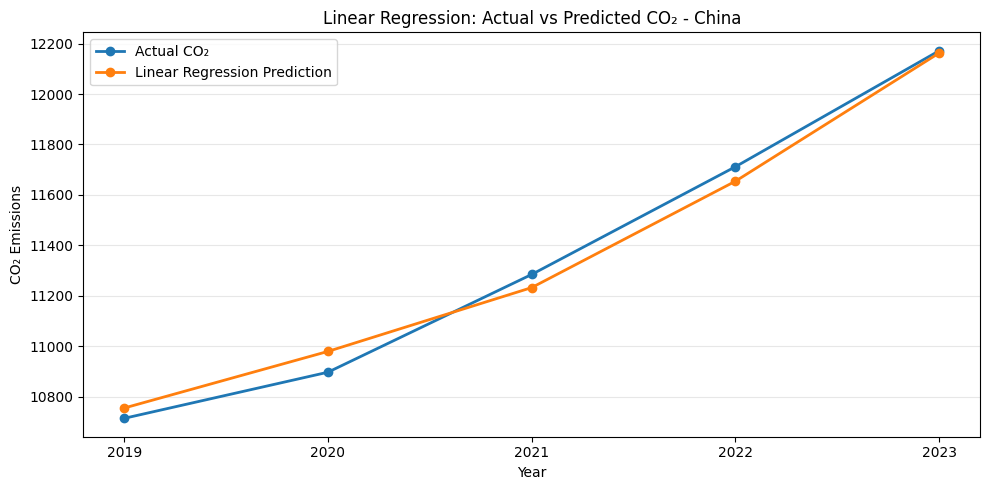

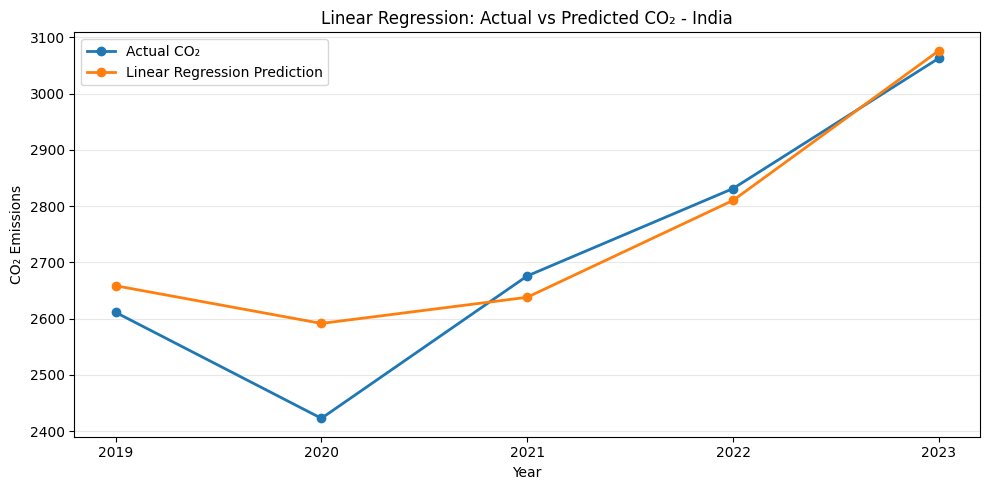

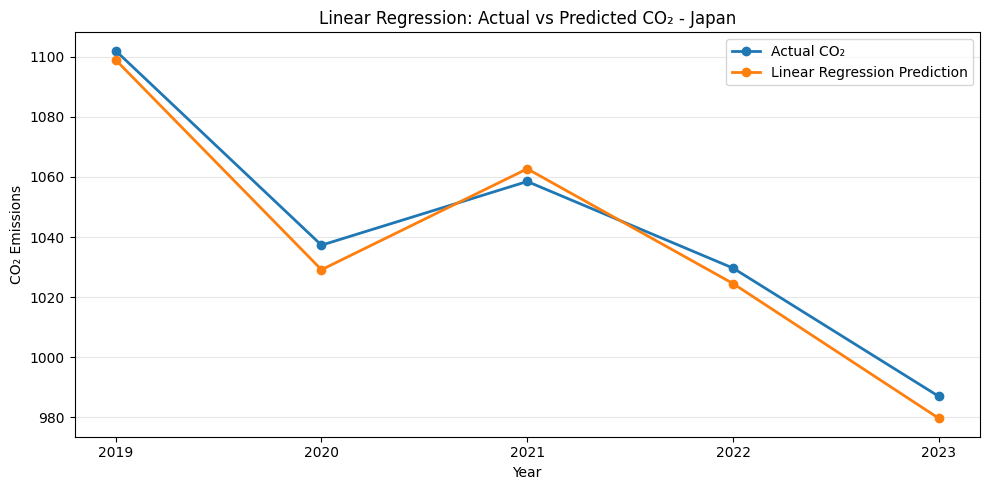

In [41]:
#Plot
plot_countries=['China', 'India', 'Japan']

for country in plot_countries:
    data=test_data[test_data['country']==country].copy()
    data=data.dropna(subset=features + [target])
    
    model=lr_models[country]
    X_test=data[features]
    data['prediction']=model.predict(X_test)

    plt.figure(figsize=(10,5))
    plt.plot(
        data['year'],
        data['co2'],
        marker='o',
        linewidth=2,
        label='Actual CO₂'
    )
    plt.plot(
        data['year'],
        data['prediction'],
        marker='o',
        linewidth=2,
        label='Linear Regression Prediction'
    )
    plt.title(f"Linear Regression: Actual vs Predicted CO₂ - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.xticks(data['year'])
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [42]:
coefficients={}
for country, model in lr_models.items():
    coefficients[country]=pd.Series(model.coef_,index=features)

coefficients_df=pd.DataFrame(coefficients)
coefficients_df

,China,India,Japan,United States,Russia,Germany,United Kingdom,Brazil,Canada,Australia
co2_5yr_rolling_mean,0.828923,0.719064,0.076573,0.012016,0.149026,0.030381,-0.065191,0.257980,-0.033997,0.187672
co2_lag1,0.854429,0.666288,0.967936,1.008069,0.921560,1.011817,1.012785,0.960887,1.038602,0.964284
co2_lag2,-0.214263,0.009446,-0.002094,0.003305,-0.037519,-0.018799,0.003166,-0.102266,0.011225,-0.037045
co2_lag3,-0.443617,-0.355443,-0.042055,-0.020657,-0.076199,-0.001860,0.007716,-0.118064,0.008758,-0.082382
co2_yoy_pct_change,40.513672,10.447727,12.173657,57.487423,15.530156,8.596224,5.253827,4.138917,5.768779,3.702155
years_since_1990,-0.430497,1.137756,0.020623,0.360577,0.430237,0.233802,-0.119420,0.366697,0.029906,-0.066502


### Interpretation of Linear Regression:

The coefficients indicate how each input feature affects the predicted CO₂ emissions.

- A positive coefficient means that an increase in the feature is associated with an increase in predicted CO₂ emissions.
- A negative coefficient indicates an inverse relationship.
- Features with larger absolute coefficient values have a stronger influence on predictions.

The lag features (`co2_lag1`, `co2_lag2`, and `co2_lag3`) are expected to have significant influence because CO₂ emissions usually show strong dependence on previous years' emissions.

The `co2_5yr_rolling_mean` feature helps the model capture long-term emission trends by smoothing short-term fluctuations.

The importance of `co2_per_capita` and `ghg_intensity` varies between countries because population size, economic activity, and energy usage patterns differ.

Overall, the coefficients show that historical emission patterns are the most influential factors for predicting future CO₂ emissions.

### Random Forest Regressor:

A Random Forest Regressor is implemented to predict future CO₂ emissions using the same feature set used for Linear Regression. Random Forest is an ensemble learning method that combines multiple decision trees to capture complex relationships between input features and CO₂ emissions.

The model parameters used are:
- Number of trees (`n_estimators`) = 100
- Random state (`random_state`) = 42

Tree complexity is limited to reduce overfitting because each country has a limited number of yearly observations.


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_data = filter_df[
    (filter_df['country'].isin(countries)) &
    (filter_df['year'] >=1990) &
    (filter_df['year'] <=2018)].copy()

test_data=filter_df[
    (filter_df['country'].isin(countries)) &
    (filter_df['year'] >=2019) &
    (filter_df['year'] <=2023)].copy()

rf_results=[]
rf_models={}
for country in countries:
    
    train_country=train_data[train_data['country']==country].copy()
    test_country=test_data[test_data['country']==country].copy()

    train_country=train_country.dropna(subset=features+[target])
    test_country=test_country.dropna(subset=features+[target])

    X_train=train_country[features]
    y_train=train_country[target]

    X_test=test_country[features]
    y_test=test_country[target]

    model=RandomForestRegressor(
    n_estimators=100,
    random_state=42)   

    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))

    rf_results.append([country, mae, rmse])
    rf_models[country]=model

rf_results=pd.DataFrame(rf_results,columns=['country','MAE','RMSE'])
rf_results

,country,MAE,RMSE
0,China,1159.169146,1276.709014
1,India,238.799492,293.539211
2,Japan,132.523026,138.120990
3,United States,359.310094,399.589100
4,Russia,27.321100,36.936964
5,Germany,113.379128,119.292176
6,United Kingdom,58.418842,62.410976
7,Brazil,13.861436,18.435043
8,Canada,17.902058,19.604822
9,Australia,13.798098,15.190216


### Interpretation:

The Random Forest model produced different prediction. Countries with larger and more variable CO₂ emissions, such as China and the United States, showed higher errors, while countries with more stable emission patterns generally had lower errors.

Compared with Linear Regression, the Random Forest model achieved lower accuracy for this dataset. This is likely because the available yearly observations for each country are limited, while the engineered lag and rolling features already capture the temporal trend effectively.

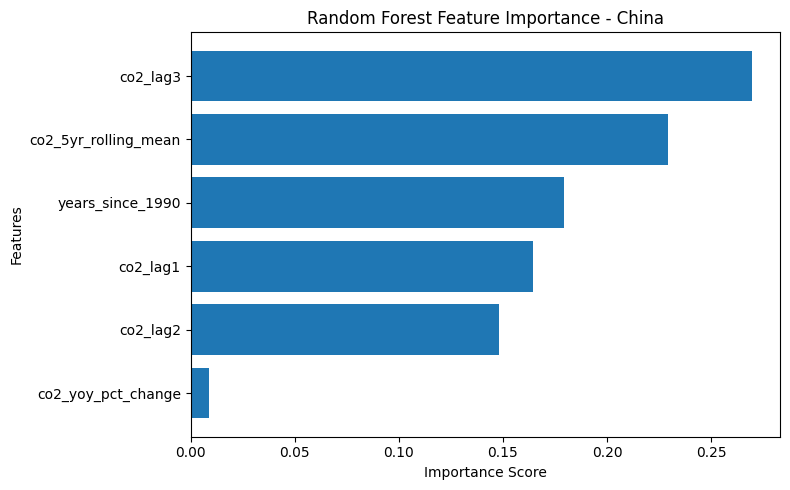

In [44]:
#Plot
country="China"

model=rf_models[country]

feature_importance=pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by='Importance',ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title(f"Random Forest Feature Importance - {country}")
plt.tight_layout()
plt.show()

## Feature Importance:

Feature importance was calculated from the trained Random Forest model to identify which input features contribute most to CO₂ emission predictions.

The importance score represents the relative contribution of each feature in the model. Features related to previous CO₂ values, such as lag variables and rolling averages, are having higher importance because emissions usually follow a time-dependent trend.

### Model Comparision table

In [45]:
comparison=baseline_results.merge(
    lr_results,on='country',suffixes=('_Baseline', '_LR'))

comparison=comparison.merge(
    rf_results,on='country')

comparison=comparison.rename(
    columns={
        'MAE': 'RF MAE',
        'RMSE': 'RF RMSE',
        'MAE_Baseline': 'Baseline MAE',
        'RMSE_Baseline': 'Baseline RMSE',
        'MAE_LR': 'LR MAE',
        'RMSE_LR': 'LR RMSE'
    }
)

def best_model(row):
    models={
        'Baseline':row['Baseline RMSE'],
        'Linear Regression':row['LR RMSE'],
        'Random Forest':row['RF RMSE']
    }
    return min(models, key=models.get)

comparison['Best Model']=comparison.apply(best_model,axis=1)
comparison

,country,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF MAE,RF RMSE,Best Model
0,China,380.264314,380.264314,48.361967,53.991104,1159.169146,1276.709014,Linear Regression
1,India,210.551410,210.551410,57.651297,80.925158,238.799492,293.539211,Linear Regression
2,Japan,42.735691,42.735691,5.584316,5.899031,132.523026,138.120990,Linear Regression
3,United States,326.759549,326.759549,27.655346,38.543932,359.310094,399.589100,Linear Regression
4,Russia,51.010591,51.010591,1.931693,2.148285,27.321100,36.936964,Linear Regression
5,Germany,50.791896,50.791896,10.916884,12.877190,113.379128,119.292176,Linear Regression
6,United Kingdom,26.115424,26.115424,8.452217,9.918509,58.418842,62.410976,Linear Regression
7,Brazil,29.459077,29.459077,3.482761,4.168151,13.861436,18.435043,Linear Regression
8,Canada,28.667970,28.667970,0.520432,0.637063,17.902058,19.604822,Linear Regression
9,Australia,9.862915,9.862915,0.663314,0.759730,13.798098,15.190216,Linear Regression


### Results:

The Naive Baseline, Linear Regression, and Random Forest models were compared using MAE and RMSE evaluation metrics. Linear Regression achieved the lowest prediction error for all 10 countries, indicating that it effectively captured the time-dependent patterns in CO₂ emissions using the engineered features. The Random Forest model showed higher errors, which may be due to the limited number of yearly observations available for training each country-specific model. Overall, Linear Regression was selected as the best-performing model for CO₂ emission forecasting.

### Summary of week 3
The regression models were evaluated on the 2019–2023 test period using MAE and RMSE metrics. Linear Regression achieved the most consistent performance across the selected countries, showing that engineered time-series features effectively capture emission patterns. Random Forest was also evaluated, but its performance was affected by the limited number of yearly observations available for each country.

## Week 4: ETS Time Series Forecasting

This section focuses on long-term CO₂ emission forecasting using the ETS(A,Ad,N) state-space model with Holt's damped trend method. The model is trained on historical emissions data and used to generate forecasts from 2024 to 2043 along with confidence intervals. The damped trend approach helps produce realistic long-term projections by reducing the influence of historical trends over time.

### ETS(A,Ad,N) — Holt's Damped Trend Model:

The ETS (Error, Trend, Seasonality) framework is a state-space framework used for time-series forecasting. It has three main components:

- Error (E): Additive Error (A) 
  The difference between the observed value and the predicted value is treated as an additive residual. This error component allows the model to update its estimates based on past forecasting errors.

- Trend (T): Additive Damped Trend (Ad) 
  The model includes an additive trend component with a damping parameter (φ), where 0 < φ < 1. The damping parameter gradually reduces the effect of the trend over future forecast, preventing unrealistic long-term growth or decline.

- Seasonality (S): No Seasonality (N)  
  Annual CO₂ emissions data does not contain within-year seasonal patterns, so no seasonal component is included.

### Why ETS(A,Ad,N) is appropriate for annual CO₂ emissions forecasting?

- Annual emissions data does not contain seasonal variations within a year.
- The damped trend prevents unbounded long-term projections and provides more realistic forecasts.
- The model performs well with limited historical observations (around 30 yearly data points) because it requires fewer parameters compared to many alternative forecasting approaches.
- The damped trend assumption is physically meaningful because real-world emissions usually slow down, stabilize, or gradually change direction rather than continuing to increase or decrease at a constant rate indefinitely.

Therefore, ETS(A,Ad,N) is an appropriate model for generating long-term CO₂ emission forecasts.

In [46]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_models={}
ets_params=[]

for country in countries:
    train_country=train_data[
        train_data['country']==country].copy()

    train_country=train_country.sort_values('year')
    train_co2=train_country.set_index('year')['co2']

    # ETS(A,Ad,N) model
    model=ExponentialSmoothing(
        train_co2,
        trend='add',
        damped_trend=True,
        seasonal=None
    )
    fit=model.fit(optimized=True)

    ets_models[country]=fit
    ets_params.append([
        country,
        fit.params['smoothing_level'],
        fit.params['smoothing_trend'],
        fit.params['damping_trend']
    ])
ets_params=pd.DataFrame(
    ets_params,
    columns=[
        'Country',
        'Alpha (α)',
        'Beta (β*)',
        'Damping (φ)'
    ]
)

ets_params

,Country,Alpha (α),Beta (β*),Damping (φ)
0,China,1.000000e+00,8.652732e-01,0.872983
1,India,6.455637e-01,6.455637e-01,0.995000
2,Japan,1.000000e+00,0.000000e+00,0.835576
3,United States,7.212633e-01,1.878731e-01,0.869549
4,Russia,4.390067e-01,4.390067e-01,0.800000
5,Germany,1.490116e-08,1.490116e-08,0.968658
6,United Kingdom,5.214694e-01,3.994607e-01,0.975702
7,Brazil,1.000000e+00,0.000000e+00,0.970057
8,Canada,8.380393e-01,0.000000e+00,0.924024
9,Australia,1.000000e+00,6.352540e-01,0.891408


In [47]:
ets_params[
    ets_params['Country'].isin(
        ['China', 'India', 'Japan']
    )
]

,Country,Alpha (α),Beta (β*),Damping (φ)
0,China,1.000000,0.865273,0.872983
1,India,0.645564,0.645564,0.995000
2,Japan,1.000000,0.000000,0.835576


### Interpretation of Damping Parameter (φ):

- The damping parameter (φ) controls how much the estimated trend continues into the future forecast period.

- A high φ value (closer to 1) means that the historical trend is expected to continue for a longer period, with slower reduction in the trend effect. For example, India has a high damping value (φ ≈ 0.995), indicating that its recent emissions trend is expected to continue with minimal damping.

- A lower φ value indicates stronger damping, meaning the model gradually reduces the influence of the historical trend and moves towards a more stable long-term trajectory. For example, Japan has a lower damping value (φ ≈ 0.836), suggesting that future forecasts will rely less on the previous growth or decline trend.

In [48]:
forecast_results=[]

forecast_years=pd.period_range(
    start="2024",
    end="2043",
    freq="Y"
)

for country in countries:

    fit=ets_models[country]

    # Forecast
    forecast=fit.forecast(20)

    # Simulate 1000 future paths
    sim = fit.simulate(
    nsimulations=20,
    repetitions=1000,
    anchor="end",
    error="add"
)

    # Compute 95% confidence intervals
    lower_bound=sim.quantile(0.025, axis=1)
    upper_bound=sim.quantile(0.975, axis=1)

    # Align indices with forecast years
    forecast.index=forecast_years
    lower_bound.index=forecast_years
    upper_bound.index=forecast_years

    # Store results
    for year in forecast_years:
        forecast_results.append([
            country,
            year.year,
            forecast.loc[year],
            lower_bound.loc[year],
            upper_bound.loc[year]
        ])

forecast_df=pd.DataFrame(
    forecast_results,
    columns=[
        "Country",
        "Year",
        "Forecast_CO2",
        "Lower_95_CI",
        "Upper_95_CI"
    ]
)

forecast_df.head()

,Country,Year,Forecast_CO2,Lower_95_CI,Upper_95_CI
0,China,2024,10629.823090,10152.606623,11071.390452
1,China,2025,10876.906034,9920.167144,11833.956576
2,China,2026,11092.605127,9670.219976,12592.320058
3,China,2027,11280.906667,9237.072037,13356.215434
4,China,2028,11445.290620,8882.263750,14079.375004


### ETS Forecast Results (2024–2043)

The fitted ETS(A,Ad,N) models were used to forecast CO₂ emissions for the period 2024–2043.

The forecast values represent the expected future CO₂ emissions based on historical trends from the training period (1990–2018). The 95% confidence intervals provide an uncertainty range around each forecast, indicating the possible variation in future emissions.

For example, China's forecast shows a gradual increase in projected CO₂ emissions in the initial forecast years, while the confidence interval represents the uncertainty associated with long-term predictions. The damped trend component prevents the model from assuming unlimited growth and produces more realistic long-term emission trajectories.

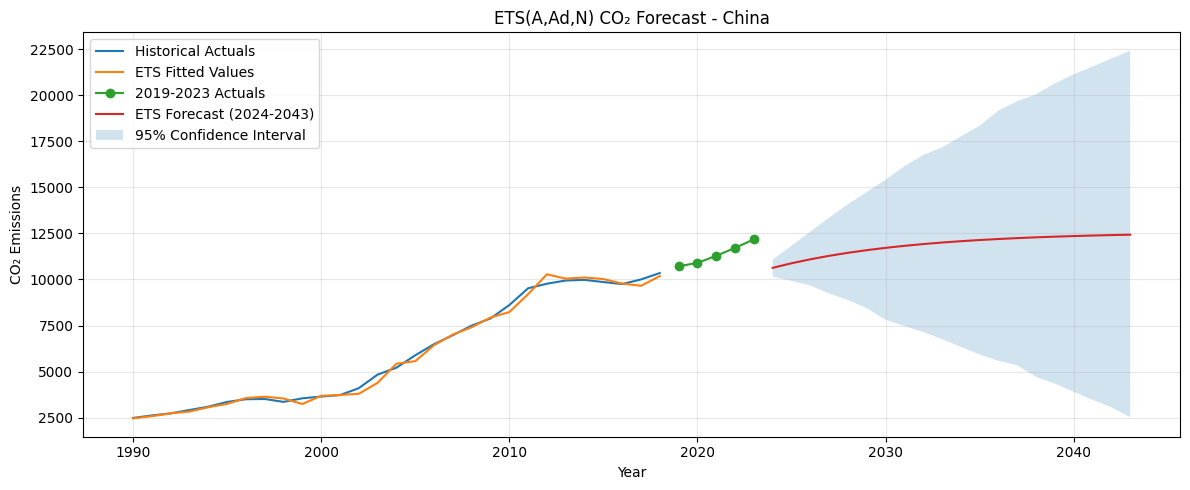

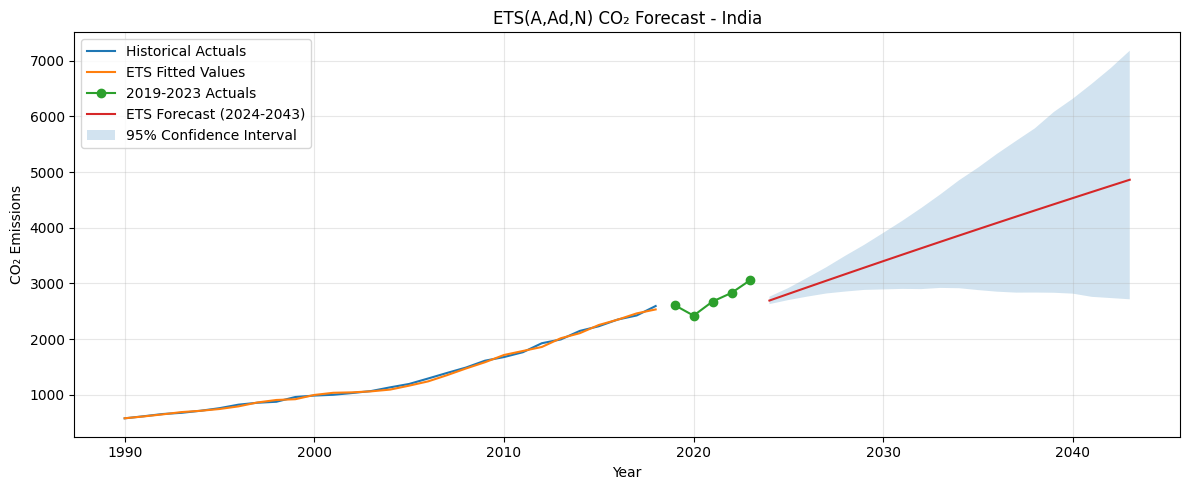

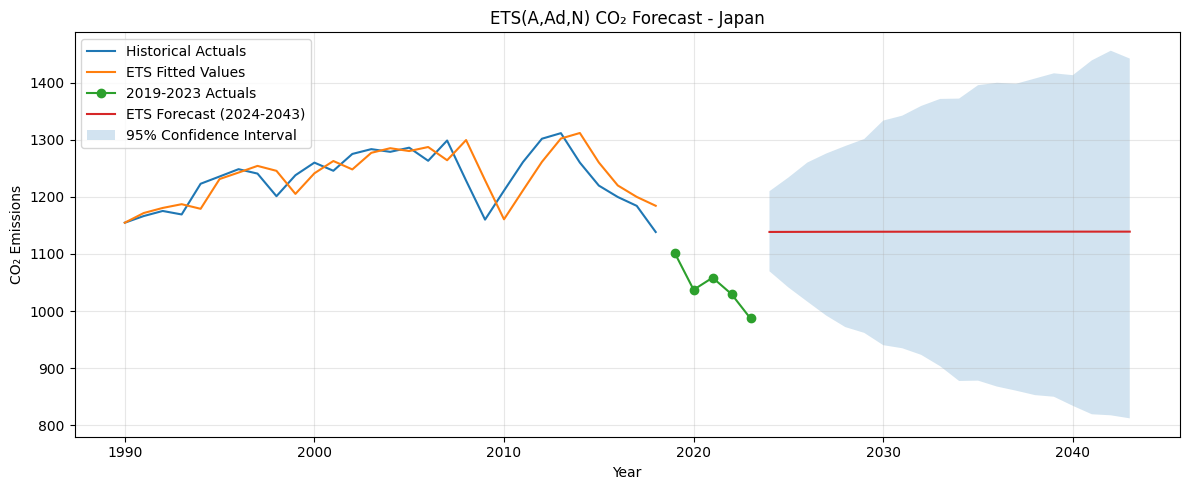

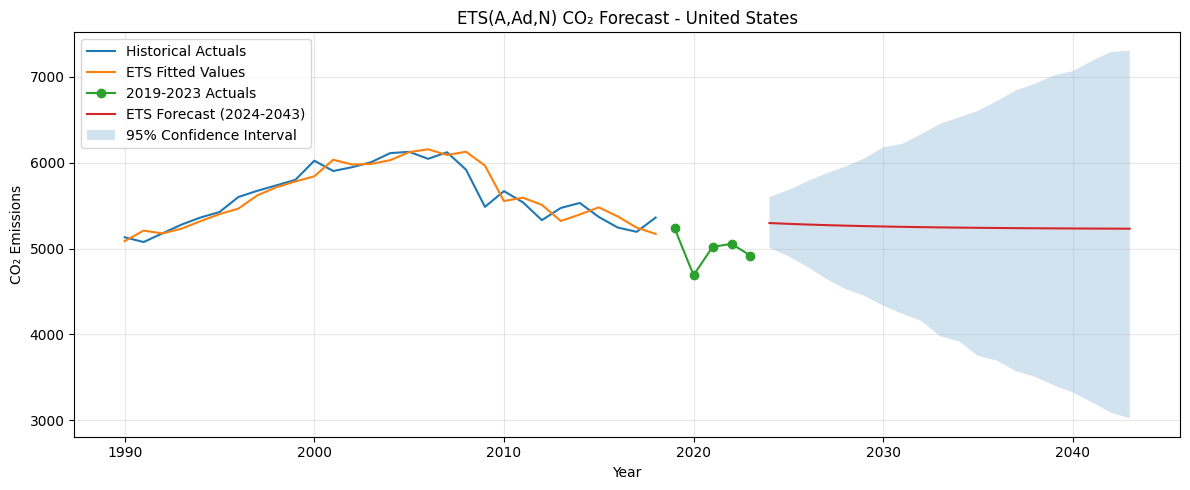

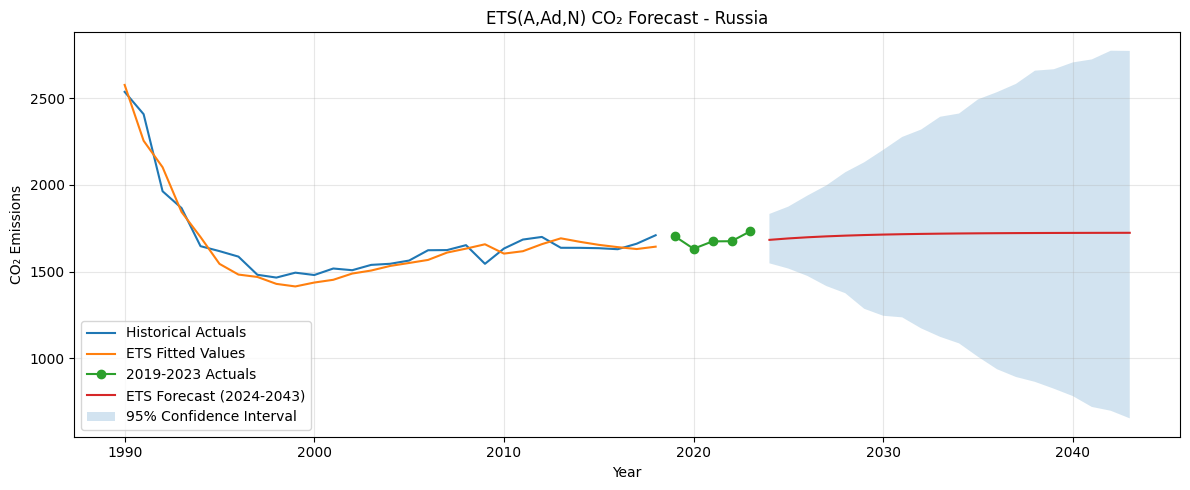

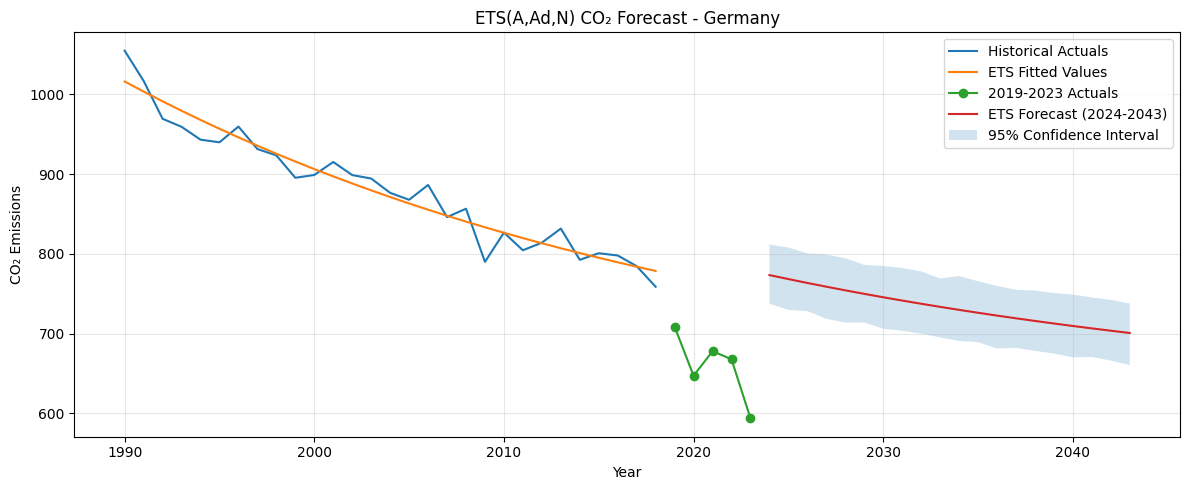

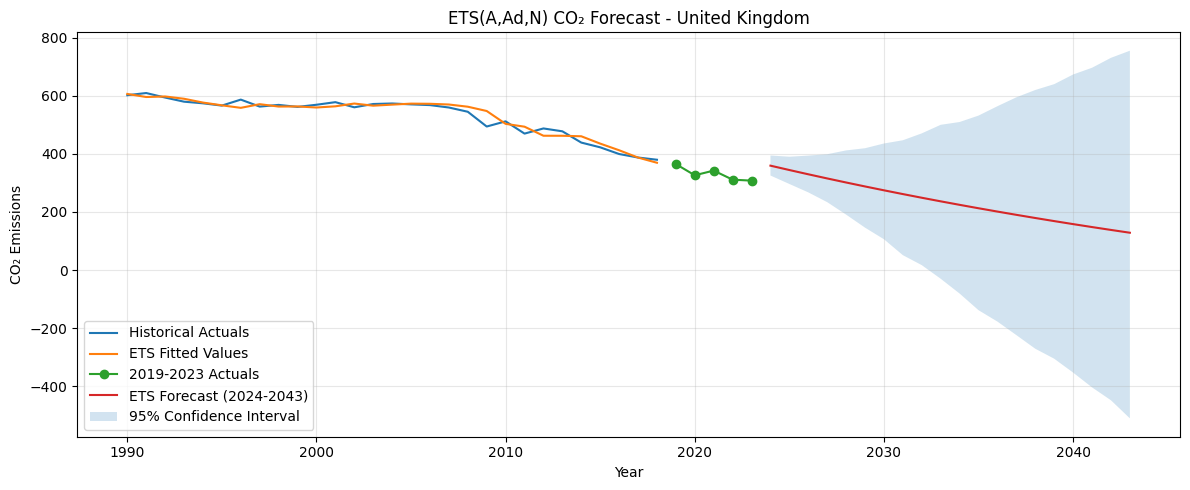

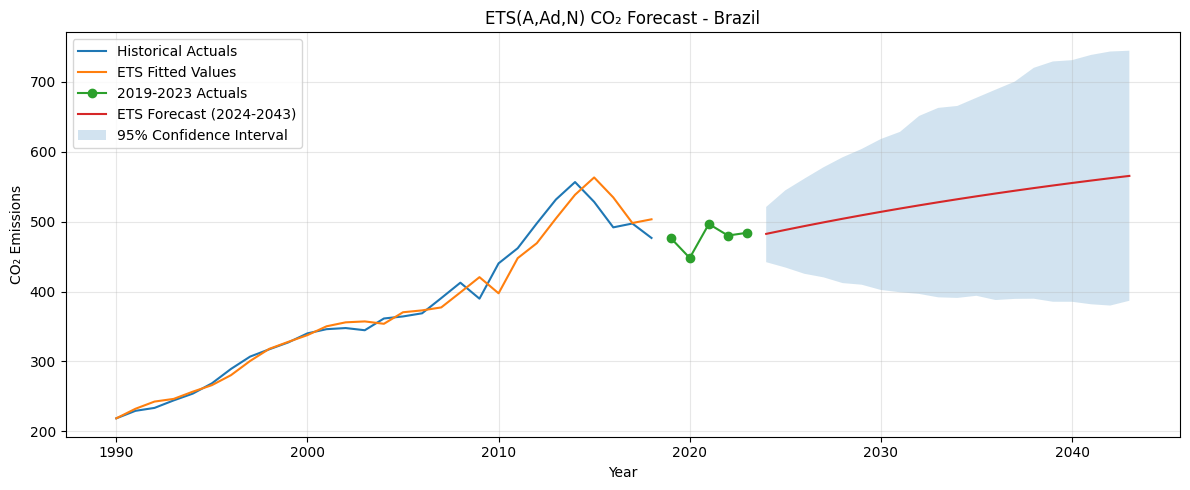

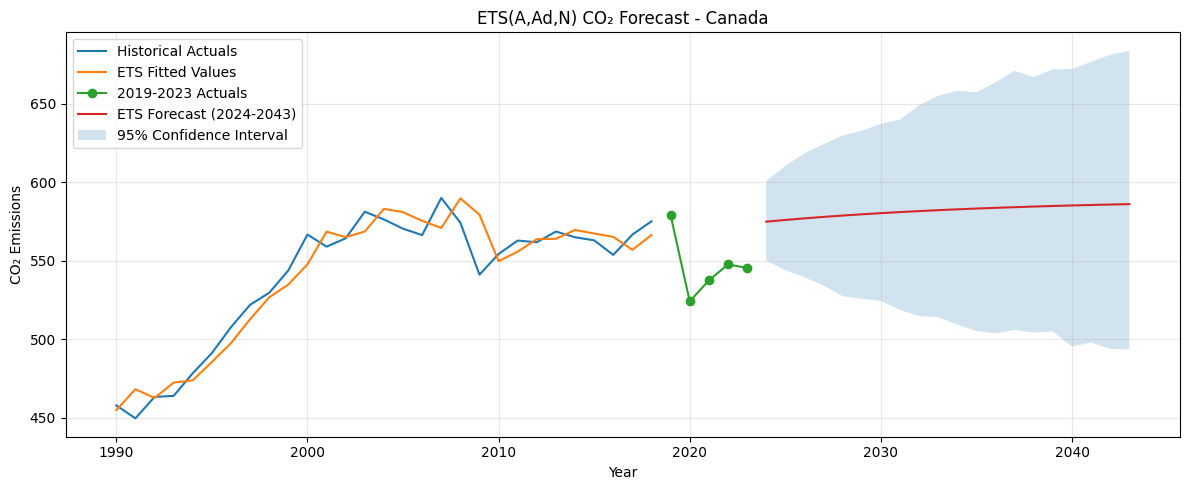

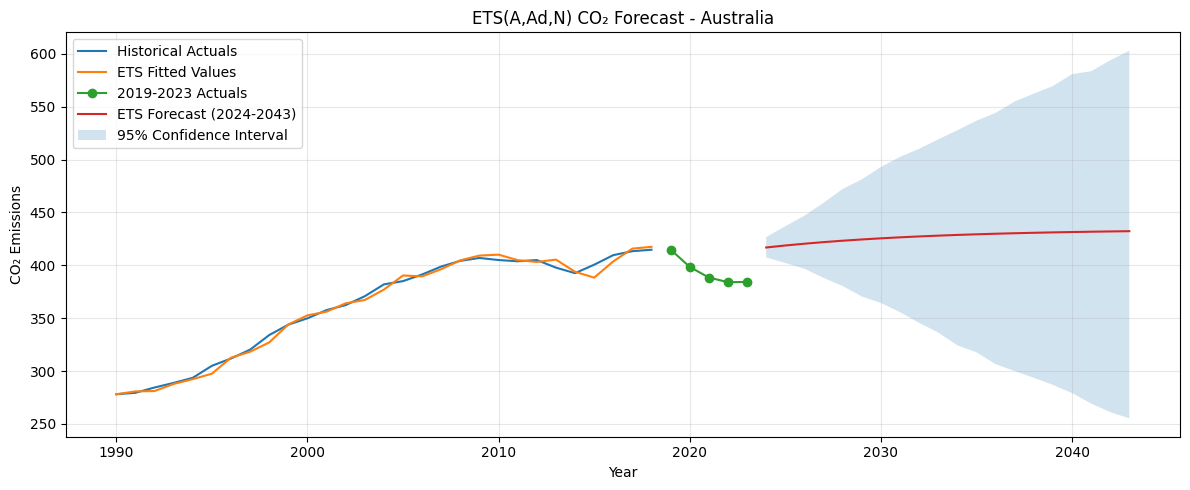

In [49]:
for country in countries:

    #training data (1990-2018)
    train_country=train_data[
        train_data['country']==country].sort_values('year')

    #test data (2019-2023)
    test_country=test_data[
        test_data['country']==country].sort_values('year')

    fit=ets_models[country]
    fitted_values=pd.Series(
        fit.fittedvalues.values,
        index=train_country['year'])

    # Forecast(2024-2043)
    forecast_country = forecast_df[
    forecast_df['Country'] == country].sort_values('Year')
    
    plt.figure(figsize=(12,5))
    plt.plot(
        train_country['year'],
        train_country['co2'],
        label='Historical Actuals'
    )

    plt.plot(
        fitted_values.index,
        fitted_values.values,
        label='ETS Fitted Values'
    )
    plt.plot(
        test_country['year'],
        test_country['co2'],
        marker='o',
        label='2019-2023 Actuals'
    )

    plt.plot(
        forecast_country['Year'],
        forecast_country['Forecast_CO2'],
        label='ETS Forecast (2024-2043)'
    )

    # Confidence interval
    plt.fill_between(
        forecast_country['Year'],
        forecast_country['Lower_95_CI'],
        forecast_country['Upper_95_CI'],
        alpha=0.2,
        label='95% Confidence Interval'
    )
    plt.title(f"ETS(A,Ad,N) CO₂ Forecast - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Trend Interpretation:

**China** - The ETS(A,Ad,N) forecast shows a gradual continuation of China's CO₂ emissions trend with the growth rate slowing over the forecast period due to the damped trend component. This is consistent with China's long-term goal of reaching peak carbon emissions before reducing emissions in the future. The damped projection avoids unrealistic continuous growth and represents a more realistic stabilization pathway.

**India** - India's forecast shows a continued increase in CO₂ emissions over the coming years, reflecting its ongoing economic growth and increasing energy demand. The high damping parameter (φ close to 1) allows the existing trend to continue for a longer period, which aligns with India's current development trajectory.

**United Kingdom** - The United Kingdom shows a declining CO₂ emissions trajectory in the forecast period. This is consistent with historical emission reductions driven by carbon reduction policies, renewable energy adoption, and changes in the energy sector. The damped trend model captures this gradual decline without assuming an unlimited reduction rate.

### Confidence Interval Analysis:

The confidence intervals generally become wider as the forecast horizon increases from 2024 to 2043. This widening reflects increasing uncertainty in long-term predictions because future emissions depend on many external factors such as economic changes, energy policies, technological improvements, and climate actions. Therefore, forecasts further into the future should be interpreted as possible trends rather than exact emission values.

In [50]:
#Forecast summary
forecast_summary=forecast_df[
    forecast_df['Year'].isin([2030, 2035, 2040])
].pivot(
    index='Country',
    columns='Year',
    values='Forecast_CO2').reset_index()

forecast_summary=forecast_summary.rename(
    columns={
        2030: '2030 Forecast (MtCO₂)',
        2035: '2035 Forecast (MtCO₂)',
        2040: '2040 Forecast (MtCO₂)'
    }
)

co2_2020=filter_df[
    (filter_df['year']==2020) &
    (filter_df['country'].isin(countries))
][['country','co2']].rename(
    columns={'country':'Country','co2':'2020 Actual'})

forecast_summary=forecast_summary.merge(
    co2_2020,
    on='Country',
    how='left')

forecast_summary['% Change 2020 → 2040']=(
    (forecast_summary['2040 Forecast (MtCO₂)']-forecast_summary['2020 Actual'])/forecast_summary['2020 Actual'])*100
forecast_summary

,Country,2030 Forecast (MtCO₂),2035 Forecast (MtCO₂),2040 Forecast (MtCO₂),2020 Actual,% Change 2020 → 2040
0,Australia,425.560937,429.373841,431.519888,398.547,8.273275
1,Brazil,513.931816,536.130246,555.198411,447.999,23.928493
2,Canada,580.281976,583.199981,585.165613,524.208,11.628516
3,China,11714.071703,12138.534046,12353.746265,10896.521,13.373308
4,Germany,745.610619,726.166555,709.584467,647.177,9.643029
5,India,3401.084264,3974.680846,4534.080197,2422.732,87.147410
6,Japan,1139.033390,1139.147243,1139.193616,1037.285,9.824553
7,Russia,1713.694794,1720.965387,1723.347815,1631.902,5.603634
8,United Kingdom,274.480687,212.720255,158.107101,326.263,-51.539984
9,United States,5257.378811,5241.980070,5234.324876,4689.954,11.607169


In [51]:
#Compute MAE and RMSE of ETS forecast against 2019-2023 for each country
from sklearn.metrics import mean_absolute_error, mean_squared_error

ets_results=[]

for country in countries:
    fit=ets_models[country]

    # Forecast period (2019-2023)
    ets_forecast=fit.forecast(5)

    actual=test_data[
        test_data['country']==country].sort_values('year')['co2'].values

    mae=mean_absolute_error(actual, ets_forecast)
    rmse=np.sqrt(mean_squared_error(actual, ets_forecast))

    ets_results.append([country,mae,rmse])

ets_results=pd.DataFrame(
    ets_results,
    columns=[
        'country',
        'ETS MAE',
        'ETS RMSE'
    ])
ets_results

,country,ETS MAE,ETS RMSE
0,China,290.544492,389.350819
1,India,210.434497,238.088325
2,Japan,95.937583,103.092444
3,United States,297.413569,346.058870
4,Russia,31.568087,34.611476
5,Germany,104.621276,109.787528
6,United Kingdom,9.367045,10.734318
7,Brazil,17.539473,21.939043
8,Canada,31.774890,35.423527
9,Australia,26.218472,29.642439


In [52]:
final_comparison=comparison.merge(
    ets_results,
    on='country',
    how='left'
)
final_comparison

,country,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF MAE,RF RMSE,Best Model,ETS MAE,ETS RMSE
0,China,380.264314,380.264314,48.361967,53.991104,1159.169146,1276.709014,Linear Regression,290.544492,389.350819
1,India,210.551410,210.551410,57.651297,80.925158,238.799492,293.539211,Linear Regression,210.434497,238.088325
2,Japan,42.735691,42.735691,5.584316,5.899031,132.523026,138.120990,Linear Regression,95.937583,103.092444
3,United States,326.759549,326.759549,27.655346,38.543932,359.310094,399.589100,Linear Regression,297.413569,346.058870
4,Russia,51.010591,51.010591,1.931693,2.148285,27.321100,36.936964,Linear Regression,31.568087,34.611476
5,Germany,50.791896,50.791896,10.916884,12.877190,113.379128,119.292176,Linear Regression,104.621276,109.787528
6,United Kingdom,26.115424,26.115424,8.452217,9.918509,58.418842,62.410976,Linear Regression,9.367045,10.734318
7,Brazil,29.459077,29.459077,3.482761,4.168151,13.861436,18.435043,Linear Regression,17.539473,21.939043
8,Canada,28.667970,28.667970,0.520432,0.637063,17.902058,19.604822,Linear Regression,31.774890,35.423527
9,Australia,9.862915,9.862915,0.663314,0.759730,13.798098,15.190216,Linear Regression,26.218472,29.642439


### Conclusion:

The four models were evaluated using MAE and RMSE on the 2019–2023 period. Linear Regression showed the best overall performance for most countries, indicating that the features such as lag values and rolling averages effectively captured CO₂ emission patterns. The ETS(A,Ad,N) model also performed well for countries with clear long-term trends, such as the United Kingdom, where emissions have followed a declining trajectory. Random Forest generally produced higher errors, because the country-wise datasets contain a limited number of yearly observations, making it difficult for tree-based models to learn complex patterns. Overall, Linear Regression provided the most consistent predictions, while ETS offered a useful approach for long-term emission forecasting.

In [53]:
forecast_df.to_csv("forecast_df.csv", index=False)

### Summary of week 4:
The ETS(A,Ad,N) model was successfully applied to forecast CO₂ emissions for the selected countries up to 2043. The model captured different emission trajectories, including increasing trends, stabilization, and declining patterns. Forecast validation showed that model performance varies depending on country-specific emission behaviour, while confidence intervals highlighted the uncertainty associated with long-term predictions.